# **TUGAS PRAKTIKUM**

**1. GAMMA CORRECTION**

 Gamma Correction pada citra 
---
Masukkan nilai Gamma: 3


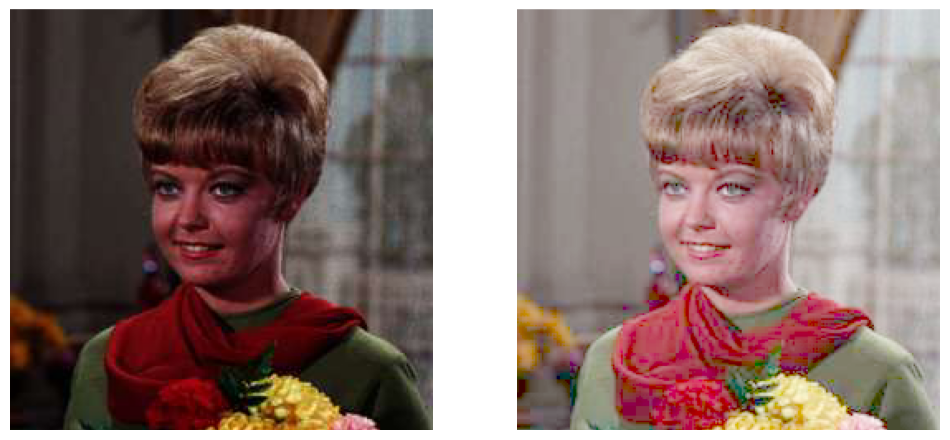

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print(' Gamma Correction pada citra ')
print('---')
try:
    gamma = float(input('Masukkan nilai Gamma: '))  # Meminta input nilai gamma dari user
except ValueError:
    print('Error, not a number')

# Membaca gambar
img = cv.imread('/content/female.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # Konversi dari BGR ke RGB

# Normalisasi pixel ke range [0,1]
img_normalized = img / 255.0

# Apply gamma correction
gamma_corrected = np.power(img_normalized, 1/gamma)  # Rumus gamma correction

# Konversi kembali ke range [0,255]
gamma_corrected = np.uint8(gamma_corrected * 255)

# Menampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(gamma_corrected)
plt.axis('off')
plt.show()

**2. SIMULASI IMAGE DEPTH**

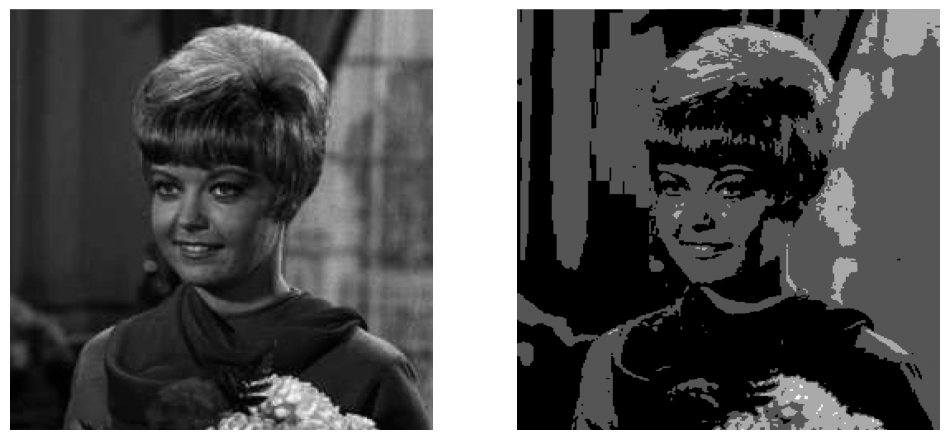

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar asli
original = cv.imread('/content/female.png', cv.IMREAD_GRAYSCALE)

bit_depth = 2  # Nilai bit depth yang diinginkan
level = 255 / (pow(2, bit_depth) - 1)  # Menghitung level kuantisasi

# Membuat array kosong dengan ukuran sama seperti gambar asli
depth_image = np.zeros(original.shape, original.dtype)

# Proses kuantisasi
for i in range(original.shape[0]):
    for j in range(original.shape[1]):
        # Kuantisasi nilai pixel
        depth_image[i,j] = round(original[i,j] / level) * level

# Menampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(original, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(depth_image, cmap='gray')
plt.axis('off')
plt.show()

**3. AVERAGE DENOISING**

Original image shape: (200, 200, 3)
Found 0 noise images
Creating simulated noise images...
Total images loaded: 100
Testing with counts: [5, 10, 20, 40, 80, 100]


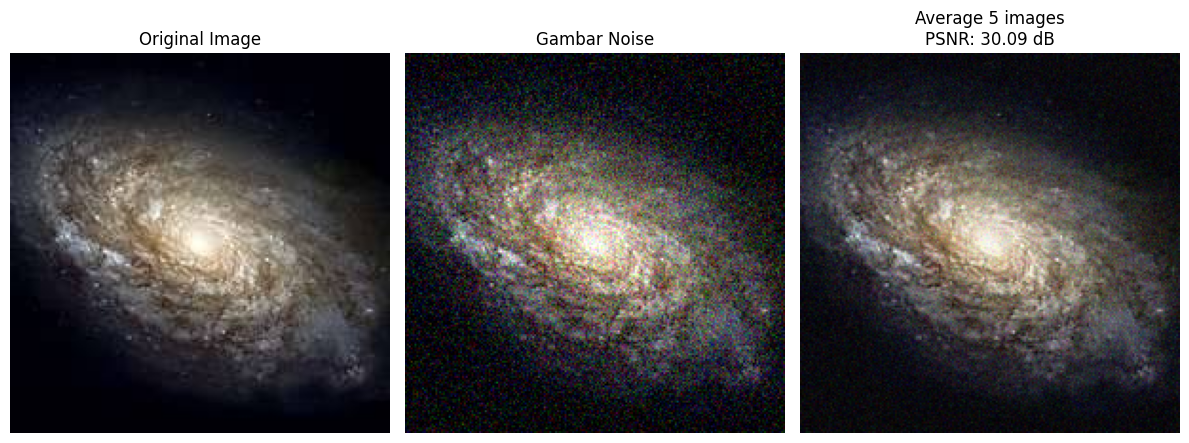

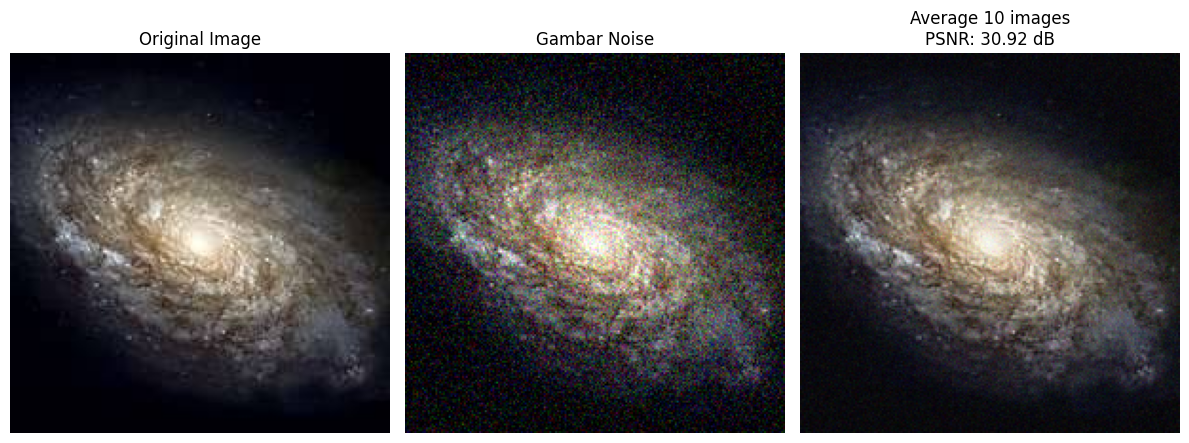

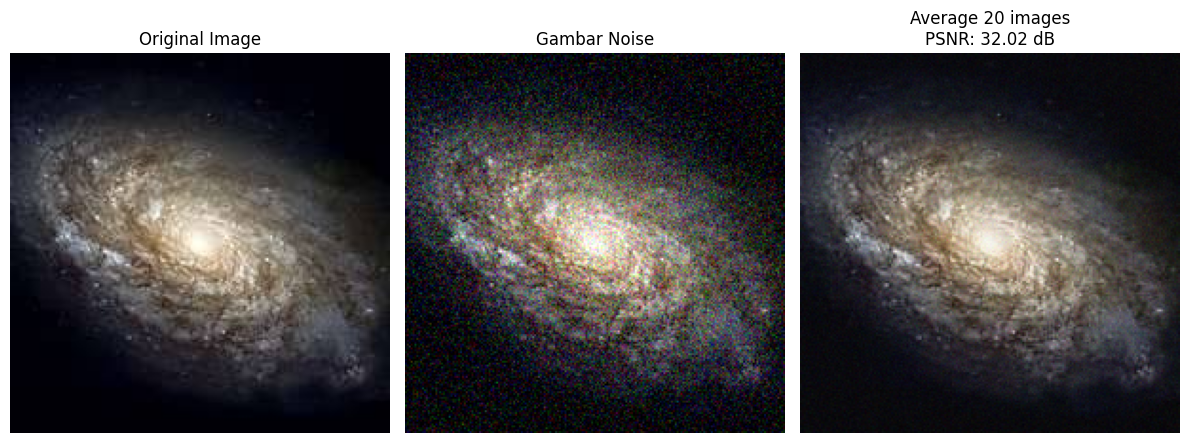

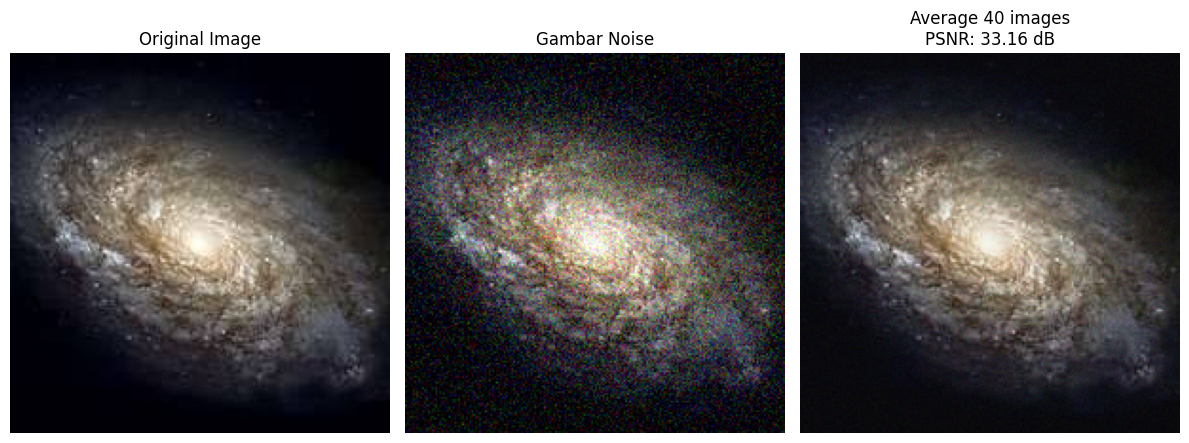

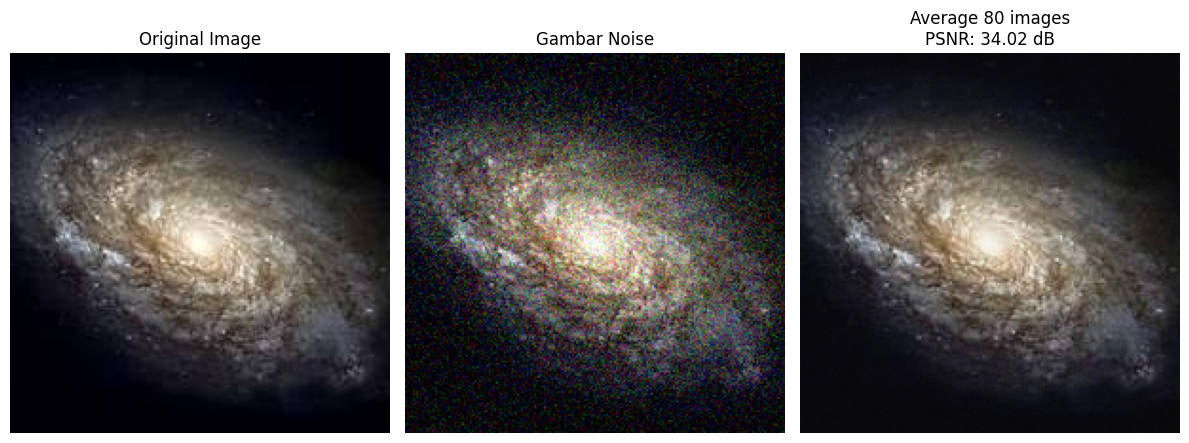

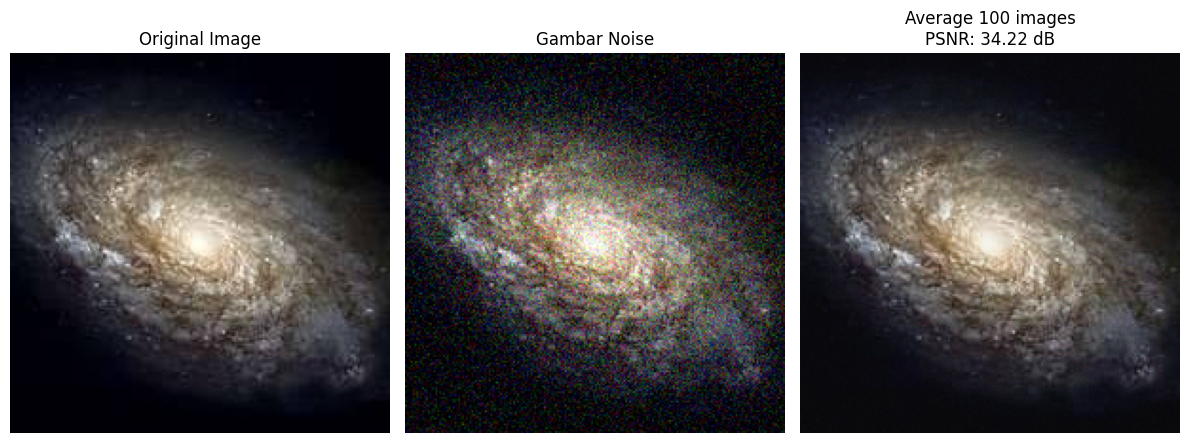


HASIL PSNR - AVERAGE DENOISING
Jumlah Citra | PSNR (dB) | Peningkatan Kualitas
--------------------------------------------------
           5 |    30.09 | 
          10 |    30.92 | (+0.83 dB)
          20 |    32.02 | (+1.10 dB)
          40 |    33.16 | (+1.15 dB)
          80 |    34.02 | (+0.86 dB)
         100 |    34.22 | (+0.20 dB)

KESIMPULAN:
Semakin banyak gambar yang dirata-ratakan, semakin tinggi nilai PSNR.
Peningkatan PSNR dari 5 ke 100 gambar: 4.13 dB
PSNR yang lebih tinggi menunjukkan kualitas gambar hasil denoising yang lebih baik


In [ ]:
import cv2 as cv
import numpy as np
import glob
from math import log10, sqrt
import matplotlib.pyplot as plt

def PSNR(img1, img2):
    mse = np.mean((img1 - img2) ** 2)  # Menghitung Mean Squared Error
    if(mse == 0):
        return 100  # Jika MSE = 0, PSNR = tak hingga (diwakili 100)
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))  # Rumus PSNR
    return psnr

# Membaca gambar asli
original_img = cv.imread('/content/images.jpg')
original_img = cv.cvtColor(original_img, cv.COLOR_BGR2RGB)

print(f"Original image shape: {original_img.shape}")

# PERBAIKAN: Path yang benar untuk membaca gambar noise
# Asumsikan gambar noise berada di folder '/content/noises/'
cv_img = []
noise_files = glob.glob('/content/noises/*.jpg')  # Baca semua file jpg di folder noises

print(f"Found {len(noise_files)} noise images")

if len(noise_files) == 0:
    # JIKA TIDAK ADA GAMBAR NOISE, BUAT SIMULASI
    print("Creating simulated noise images...")
    for i in range(100):
        # Tambahkan Gaussian noise ke gambar asli
        noise = np.random.normal(0, 25, original_img.shape).astype(np.float32)
        noisy_img = original_img.astype(np.float32) + noise
        noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)
        cv_img.append(noisy_img)
else:
    # Baca gambar noise yang ada
    for img_path in noise_files:
        n = cv.imread(img_path)
        n = cv.cvtColor(n, cv.COLOR_BGR2RGB)  # Konversi ke RGB
        cv_img.append(n)

print(f"Total images loaded: {len(cv_img)}")

# Pastikan kita punya cukup gambar untuk test
available_images = len(cv_img)
test_counts = [5, 10, 20, 40, 80, 100]
# Filter test_counts berdasarkan jumlah gambar yang tersedia
test_counts = [count for count in test_counts if count <= available_images]

if not test_counts:
    test_counts = [min(5, available_images)]  # Minimal test dengan 5 gambar

print(f"Testing with counts: {test_counts}")

results = []

for count in test_counts:
    # Average denoising
    avg_img = np.zeros_like(cv_img[0], dtype=np.float32)

    # PERBAIKAN: Pastikan tidak melebihi jumlah gambar yang ada
    actual_count = min(count, len(cv_img))

    for i in range(actual_count):
        avg_img += cv_img[i].astype(np.float32)

    avg_img = avg_img / actual_count  # Rata-rata pixel
    avg_img = np.clip(avg_img, 0, 255).astype(np.uint8)  # Konversi ke integer dengan clip

    # Hitung PSNR
    psnr_value = PSNR(original_img, avg_img)
    results.append((actual_count, avg_img, psnr_value))

    # Tampilkan hasil
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original_img)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    # Tampilkan salah satu gambar noise untuk perbandingan
    plt.imshow(cv_img[0])
    plt.title('Gambar Noise')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(avg_img)
    plt.title(f'Average {actual_count} images\nPSNR: {psnr_value:.2f} dB')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Tampilkan tabel hasil
print("\n" + "="*50)
print("HASIL PSNR - AVERAGE DENOISING")
print("="*50)
print("Jumlah Citra | PSNR (dB) | Peningkatan Kualitas")
print("-" * 50)

# Urutkan hasil berdasarkan jumlah citra
results.sort(key=lambda x: x[0])

for i, (count, img, psnr) in enumerate(results):
    improvement = ""
    if i > 0:
        prev_psnr = results[i-1][2]
        improvement = f"(+{psnr-prev_psnr:.2f} dB)"
    print(f"{count:12} | {psnr:8.2f} | {improvement}")

# Kesimpulan
print("\n" + "="*50)
print("KESIMPULAN:")
print("="*50)
if len(results) > 1:
    first_psnr = results[0][2]
    last_psnr = results[-1][2]
    improvement_total = last_psnr - first_psnr
    print(f"Semakin banyak gambar yang dirata-ratakan, semakin tinggi nilai PSNR.")
    print(f"Peningkatan PSNR dari {results[0][0]} ke {results[-1][0]} gambar: {improvement_total:.2f} dB")
    print(f"PSNR yang lebih tinggi menunjukkan kualitas gambar hasil denoising yang lebih baik")
else:
    print(f"PSNR untuk {results[0][0]} gambar: {results[0][2]:.2f} dB")

**4. IMAGE MASKING**

Ukuran gambar: 738 x 781


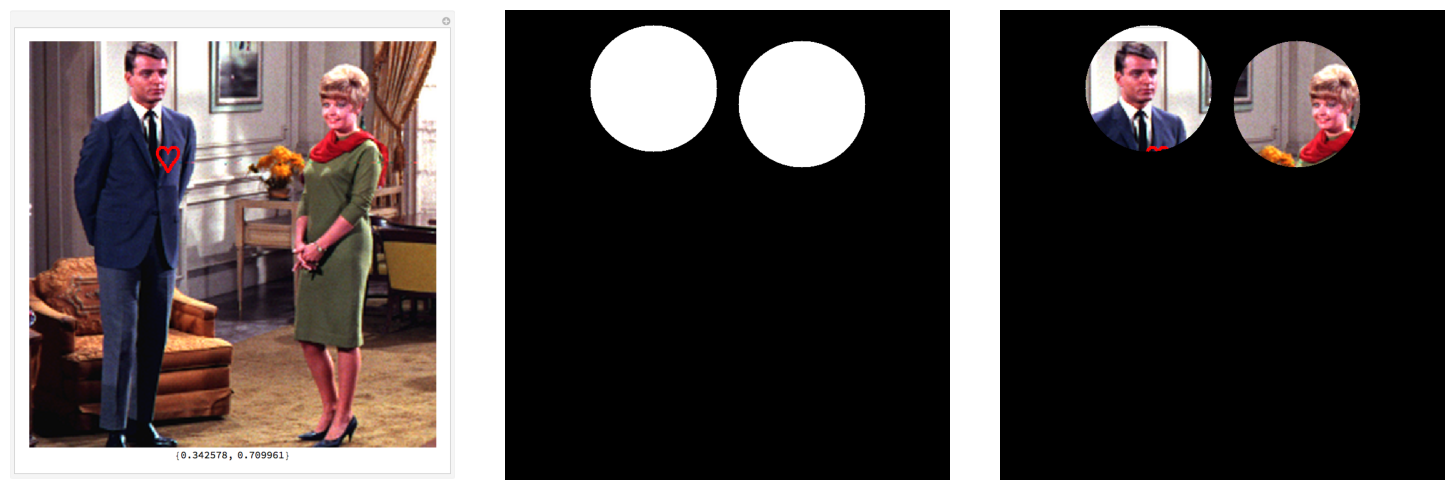

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar
img = cv.imread('/content/couple.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Membuat mask dengan 2 lingkaran putih di bagian atas (seperti mata)
mask = np.zeros(img.shape[:2], dtype=np.uint8)
height, width = img.shape[:2]

print(f"Ukuran gambar: {width} x {height}")

# Menyesuaikan posisi lingkaran agar tepat di wajah
# Lingkaran kiri (untuk wajah kiri)
center_left = (width // 3, height // 6)  # Posisi lebih ke bawah untuk wajah
radius = min(width, height) // 7  # Ukuran lingkaran lebih kecil

cv.circle(mask, center_left, radius, 255, -1)

# Lingkaran kanan (untuk wajah kanan)
center_right = (2 * width // 3, height // 5)  # Posisi lebih ke bawah untuk wajah
cv.circle(mask, center_right, radius, 255, -1)

# Apply masking dengan operator AND
masked_img = cv.bitwise_and(img, img, mask=mask)

# Menampilkan hasil
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(masked_img)
plt.axis('off')

plt.tight_layout()
plt.show()

**5. OPERATOR LOGIKA LAINNYA**


No. 1. OPERATOR: NOT (Komplement)
--------------------------------------------------


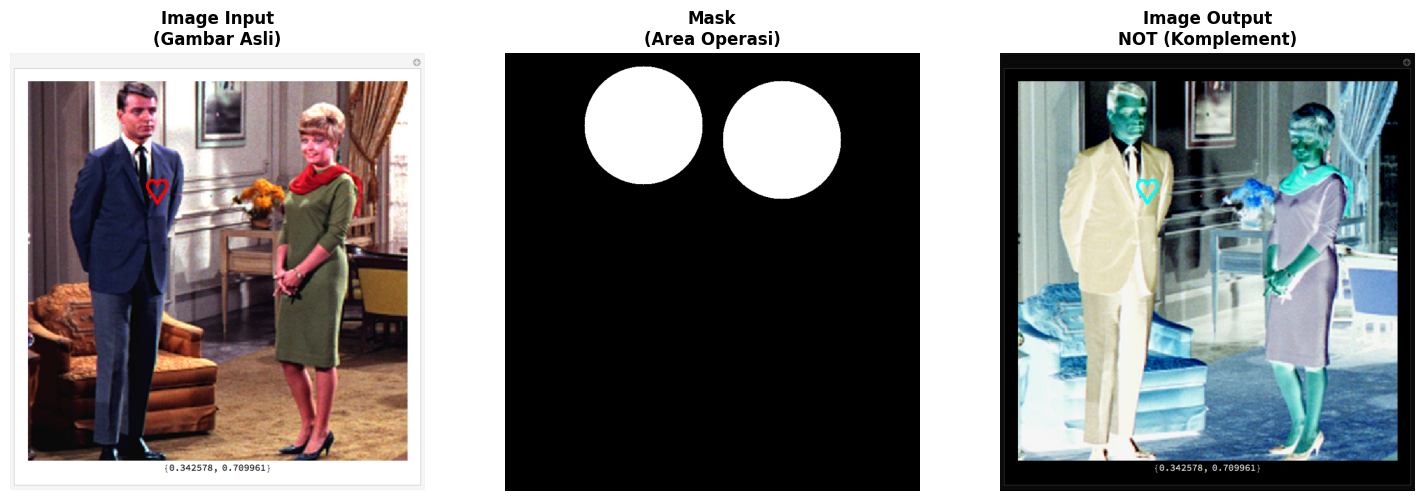


No. 2. OPERATOR: OR (Atau)
--------------------------------------------------


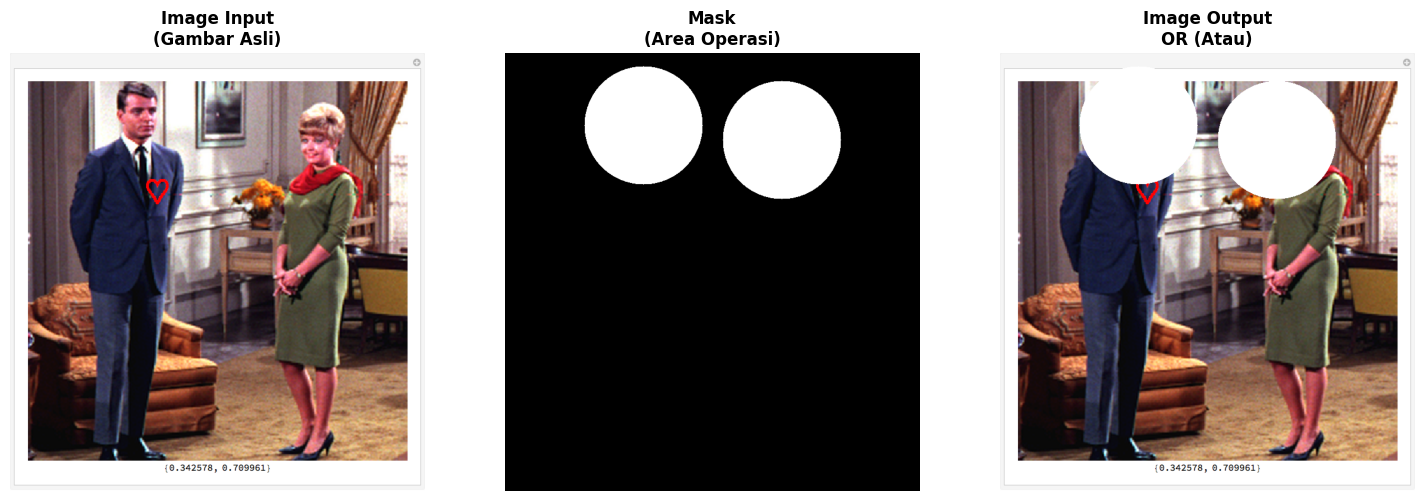


No. 3. OPERATOR: AND (Dan)
--------------------------------------------------


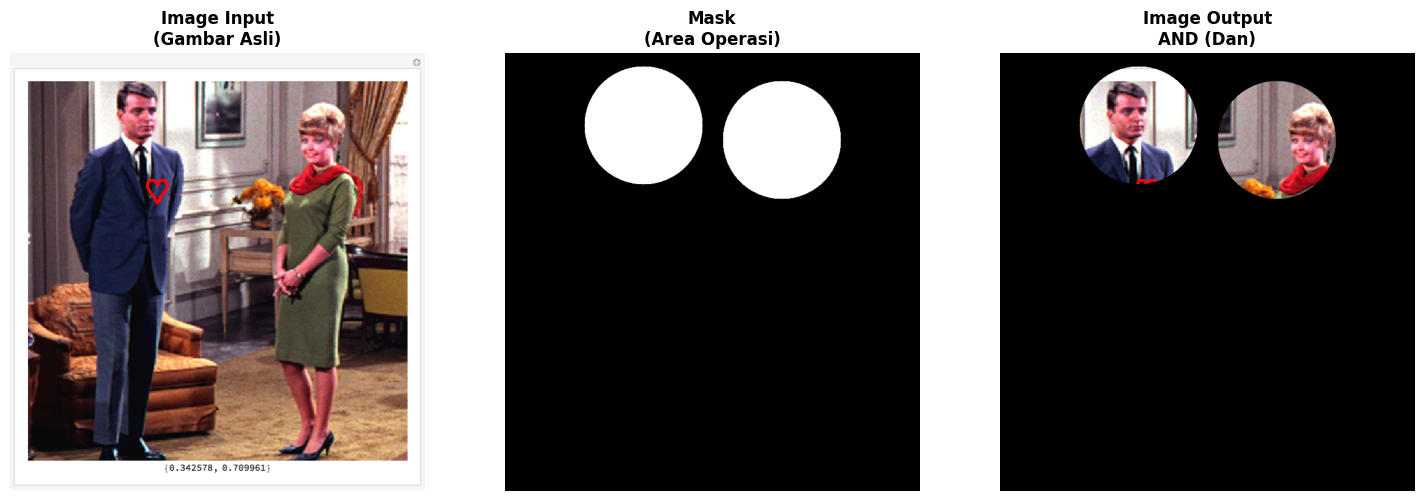


No. 4. OPERATOR: NAND (Not AND)
--------------------------------------------------


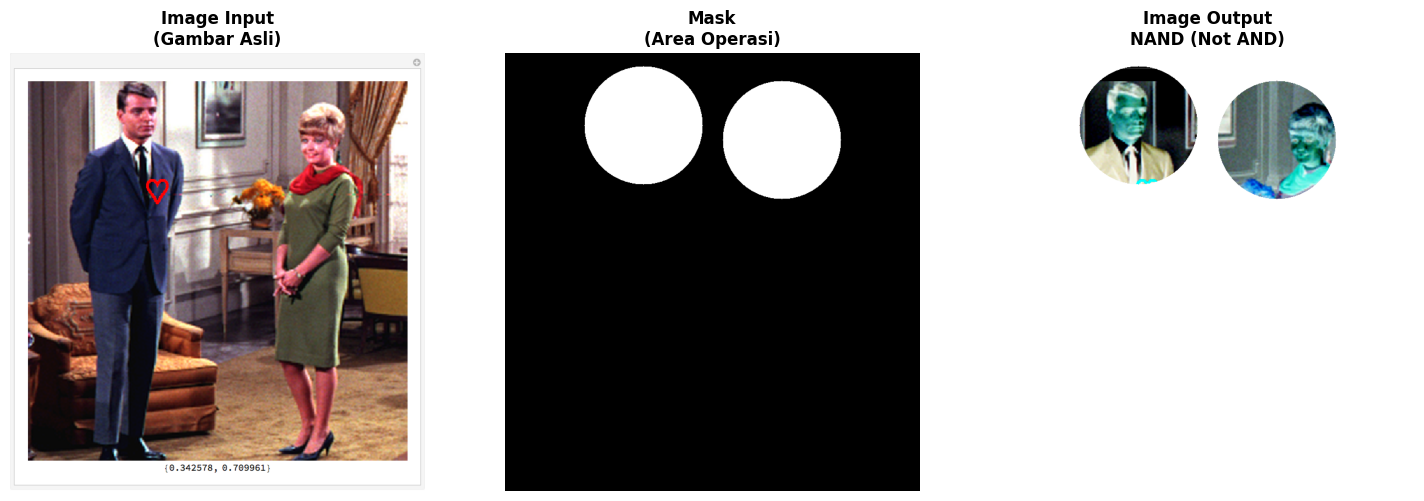


No. 5. OPERATOR: XOR (Exclusive OR)
--------------------------------------------------


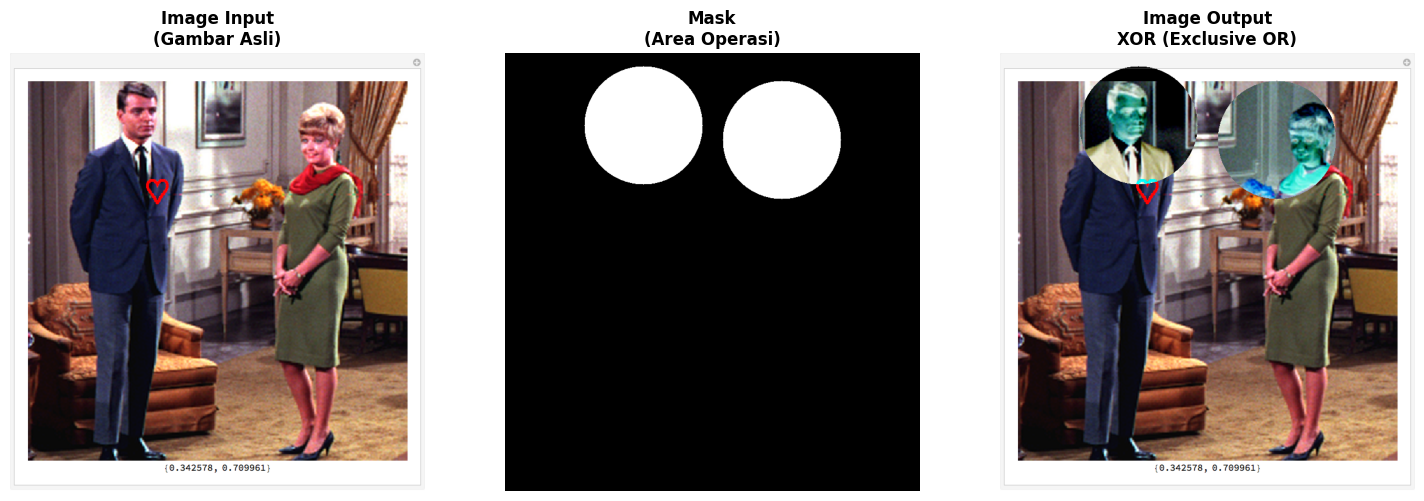

In [54]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar
img = cv.imread('/content/couple.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Membuat mask dengan 2 lingkaran putih
mask = np.zeros(img.shape[:2], dtype=np.uint8)
height, width = img.shape[:2]

center_left = (width // 3, height // 6)
center_right = (2 * width // 3, height // 5)
radius = min(width, height) // 7

cv.circle(mask, center_left, radius, 255, -1)
cv.circle(mask, center_right, radius, 255, -1)

# Konversi mask ke 3 channel untuk operasi dengan gambar berwarna
mask_3channel = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)

# OPERATOR LOGIKA
results = []

# 1. NOT (Komplement)
not_result = cv.bitwise_not(img)
results.append(('NOT (Komplement)', not_result))

# 2. OR (Atau)
or_result = cv.bitwise_or(img, mask_3channel)
results.append(('OR (Atau)', or_result))

# 3. AND (Dan)
and_result = cv.bitwise_and(img, img, mask=mask)
results.append(('AND (Dan)', and_result))

# 4. NAND (Not AND)
nand_result = cv.bitwise_not(and_result)
results.append(('NAND (Not AND)', nand_result))

# 5. XOR (Exclusive OR)
xor_result = cv.bitwise_xor(img, mask_3channel)
results.append(('XOR (Exclusive OR)', xor_result))


# Tampilkan per operator dengan layout yang jelas
for i, (operator_name, result_img) in enumerate(results, 1):
    print(f"\nNo. {i}. OPERATOR: {operator_name}")
    print("-" * 50)

    plt.figure(figsize=(15, 5))

    # Image Input
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title('Image Input\n(Gambar Asli)', fontsize=12, fontweight='bold')
    plt.axis('off')

    # Mask (untuk referensi)
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Mask\n(Area Operasi)', fontsize=12, fontweight='bold')
    plt.axis('off')

    # Image Output
    plt.subplot(1, 3, 3)
    plt.imshow(result_img)
    plt.title(f'Image Output\n{operator_name}', fontsize=12, fontweight='bold')
    plt.axis('off')

    plt.tight_layout()
    plt.show()